# FAPE, Lending Club Stage 2: ThresholdOptimizer

Phase 4, Stage 2 fairness intervention in the financial services domain, on a 100,000-record stratified sample of 1,348,099 Lending Club records (20.1% default rate). The script applies Fairlearn's ThresholdOptimizer post-processing to the baseline models under the demographic parity and equalized odds constraints. The primary sensitive attribute is `annual_inc_band`, an income quartile proxy (0 = Q1 lowest to 3 = Q4 highest). The secondary one is `home_ownership`, compared as MORTGAGE (1) against RENT (5); the sparse groups 0, 2 and 3 (n<30) are excluded from the fairness metrics. There is no direct race or gender data, so the audit rests on these proxies. The positive class is Charged Off, so a disparate impact ratio above 1.0 means the designated group is flagged for default more often, the adverse direction. ThresholdOptimizer.predict is seeded with random_state=42, so runs are identical.

Code: `src/stage2_lendingclub_threshold.py`. This notebook runs that script, so its printed output and figures are the ones the paper uses.

In [1]:
import os, sys, warnings, logging

# The data loaders read paths relative to the repository root (data/raw/...), so run from there.
# The check stops a second run of this cell from moving up another directory.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
if os.path.abspath('src') not in sys.path:
    sys.path.insert(0, os.path.abspath('src'))
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
from IPython.display import Image, display

# matplotlib 3.8.4 (pinned) imports backend2gui from IPython when a script makes its first figure
# inside a kernel, and IPython 9 removed it. An empty mapping is what IPython 8 gave for Agg.
import IPython.core.pylabtools
if not hasattr(IPython.core.pylabtools, 'backend2gui'):
    IPython.core.pylabtools.backend2gui = {}

In [2]:
from stage2_lendingclub_threshold import run_stage2

run_stage2();  # returns (baseline, dp_results, eo_results, inc_test, home_test); the semicolon keeps Jupyter from echoing it

FAPE Phase 4, Lending Club Stage 2: ThresholdOptimizer
Loading Lending Club data from data/raw/lending_club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv...


  Raw records: 2,260,701
  After binary outcome filter: 1,348,099


  Sampled to: 100,000 records
  OK: lending_club: 100,000 rows | 23 features | default rate: 0.201

  n=100,000 stratified | default_rate=20.1%
  Primary sensitive: annual_inc_band (0=Q1 lowest to 3=Q4 highest)
  Secondary: home_ownership (0=MORTGAGE vs 1=RENT)
  Note: No direct race/gender, ECOA proxy-based audit
  Note: ThresholdOptimizer.predict seeded with random_state=42

--- Baseline Results (Stage 1 reference) ---


  LogisticRegression        AUC=0.706 DP_diff=0.018 EO_diff=0.038


  GradientBoosting          AUC=0.712 DP_diff=0.024 EO_diff=0.053

--- ThresholdOptimizer, Demographic Parity Constraint ---


...

  LogisticRegression        DP_diff=0.020 EO_diff=0.047 Acc=0.569 EO_improve=-0.009


  GradientBoosting          DP_diff=0.013 EO_diff=0.049 Acc=0.661 EO_improve=+0.004

--- Fairness Improvement Summary, Income Band (DP) ---
  LogisticRegression        DP before=0.018 after=0.019 improve=-0.001
  GradientBoosting          DP before=0.024 after=0.018 improve=+0.005

--- Fairness Improvement Summary, Income Band (EO) ---
  LogisticRegression        EO before=0.038 after=0.047 improve=-0.009
  GradientBoosting          EO before=0.053 after=0.049 improve=+0.004

--- Home Ownership Fairness, MORTGAGE vs RENT ---
  LogisticRegression        Home DP_diff=0.181 (MORTGAGE vs RENT, post-DP)
  GradientBoosting          Home DP_diff=0.142 (MORTGAGE vs RENT, post-DP)

--- Income Band Prediction Rates, GB Before vs After DP ---
  Q1-Low     true default=0.238 before=0.028 after=0.401 change=+0.373
  Q2         true default=0.221 before=0.034 after=0.412 change=+0.378
  Q3         true default=0.178 before=0.016 after=0.394 change=+0.378
  Q4-High    true default=0.165 before=0.010 

Loading Lending Club data from data/raw/lending_club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv...


  Raw records: 2,260,701
  After binary outcome filter: 1,348,099


  Sampled to: 100,000 records
  OK: lending_club: 100,000 rows | 23 features | default rate: 0.201

--- Lending Club Stage 2 complete ---
  Income-based fairness intervention applied
  No direct race/gender, proxy-based ECOA audit
  Cross-domain: financial services income gap addressed


## 1. Accuracy and DPD, baseline and constrained

Accuracy and income-band demographic parity difference for each model at baseline and under each constraint.

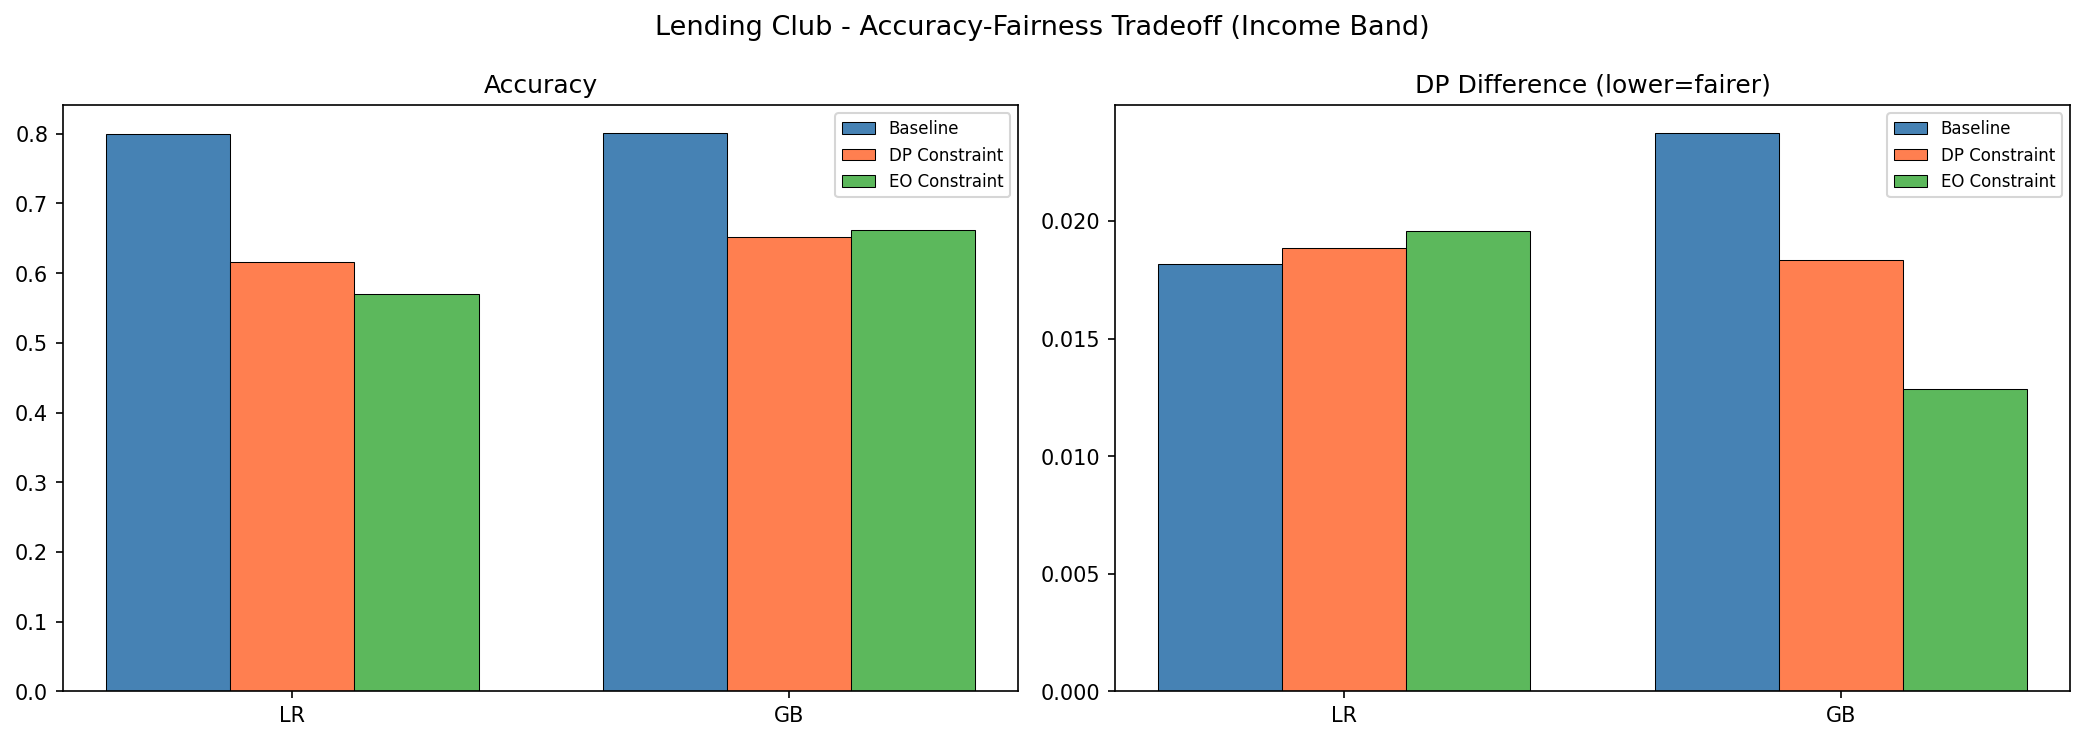

In [3]:
display(Image('figures/stage2/lendingclub_accuracy_fairness_tradeoff.png'))

## 2. Fairness improvement by constraint

Change in income-band DPD under the demographic parity constraint and in EOD under the equalized odds constraint, for each model.

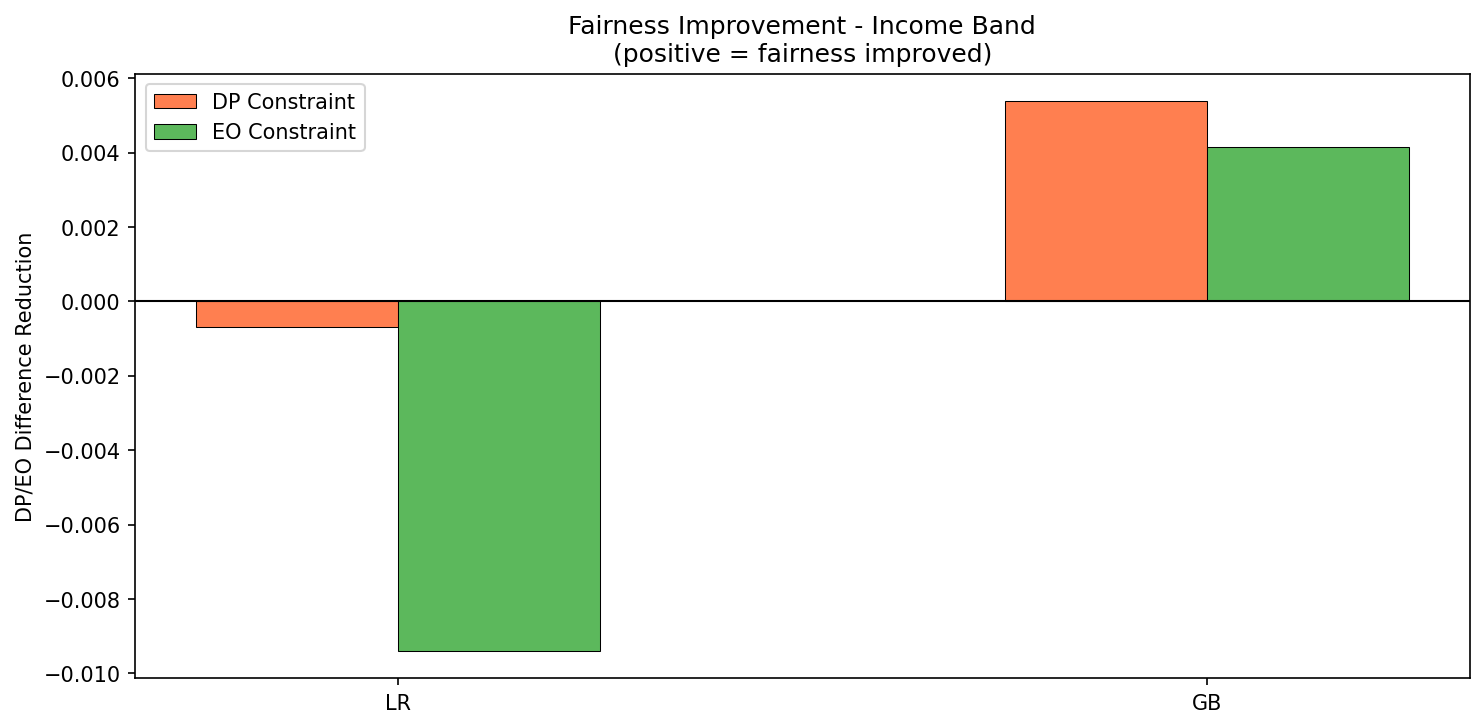

In [4]:
display(Image('figures/stage2/lendingclub_fairness_improvement.png'))

## 3. Accuracy cost against fairness gain

Each model's accuracy cost plotted against its fairness gain under each constraint.

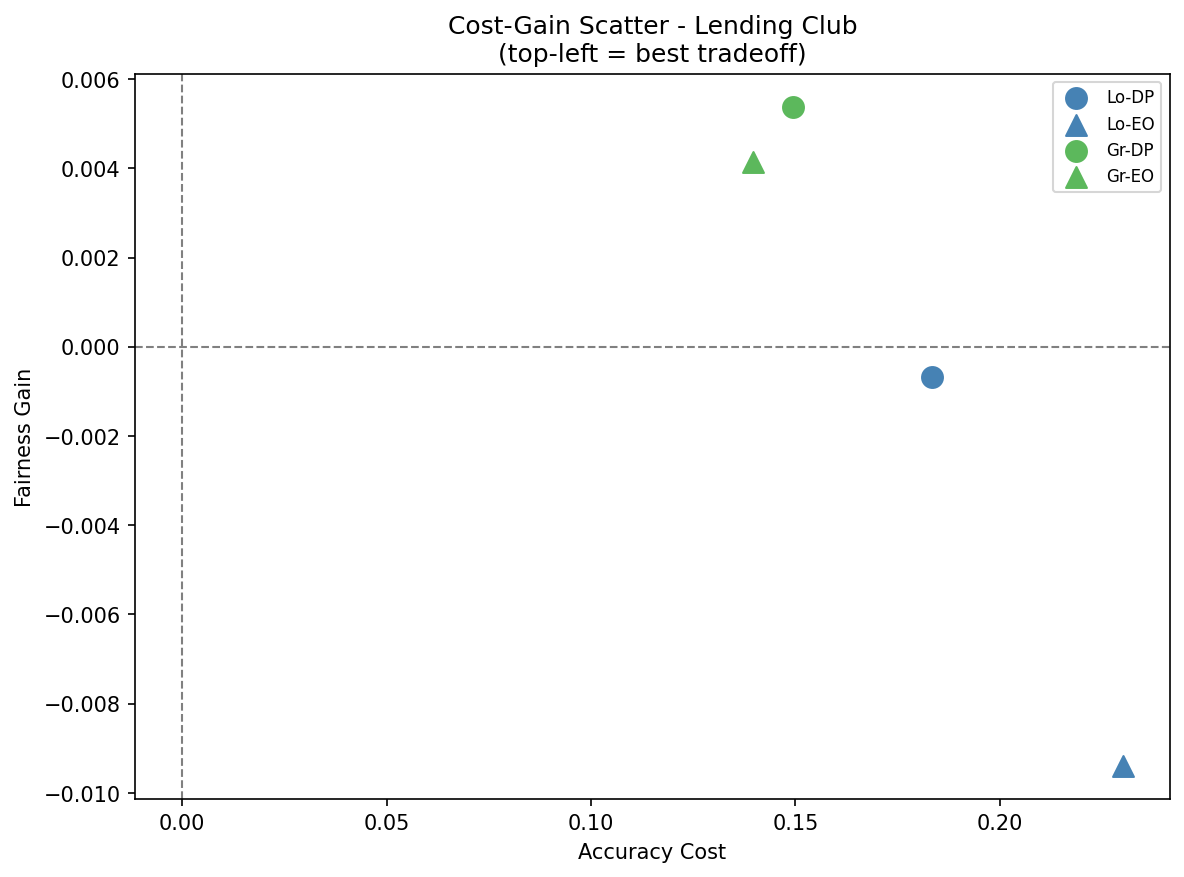

In [5]:
display(Image('figures/stage2/lendingclub_cost_gain_scatter.png'))

## 4. Predicted default rates by home ownership

Gradient boosting's predicted default rate for mortgage holders and renters, before and after the income-band demographic parity constraint.

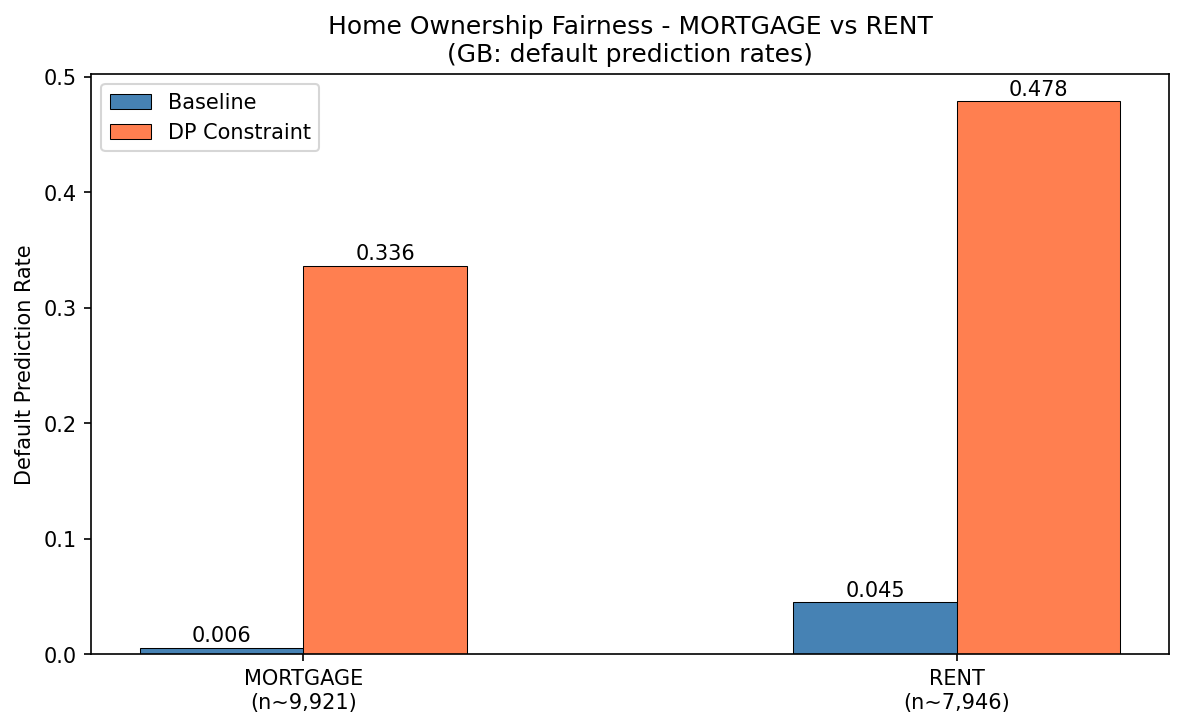

In [6]:
display(Image('figures/stage2/lendingclub_home_ownership_fairness.png'))

## 5. Predicted default rates by income band

Gradient boosting's predicted default rate for each income quartile, before and after the demographic parity constraint.

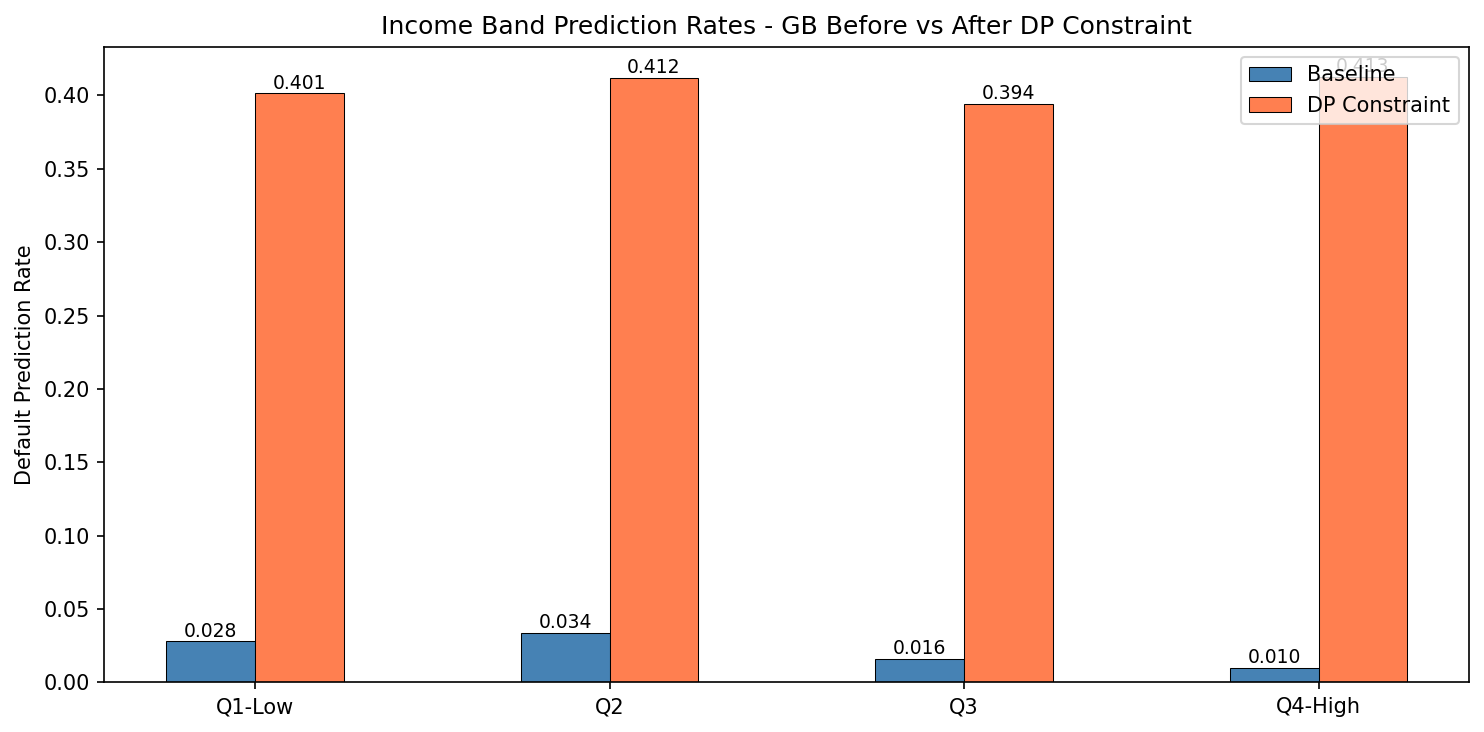

In [7]:
display(Image('figures/stage2/lendingclub_income_band_rates.png'))

## 6. Lowest-to-highest income quartile DIR

Ratio of predicted default rates between the lowest and highest income quartiles for each model, before and after the demographic parity constraint.

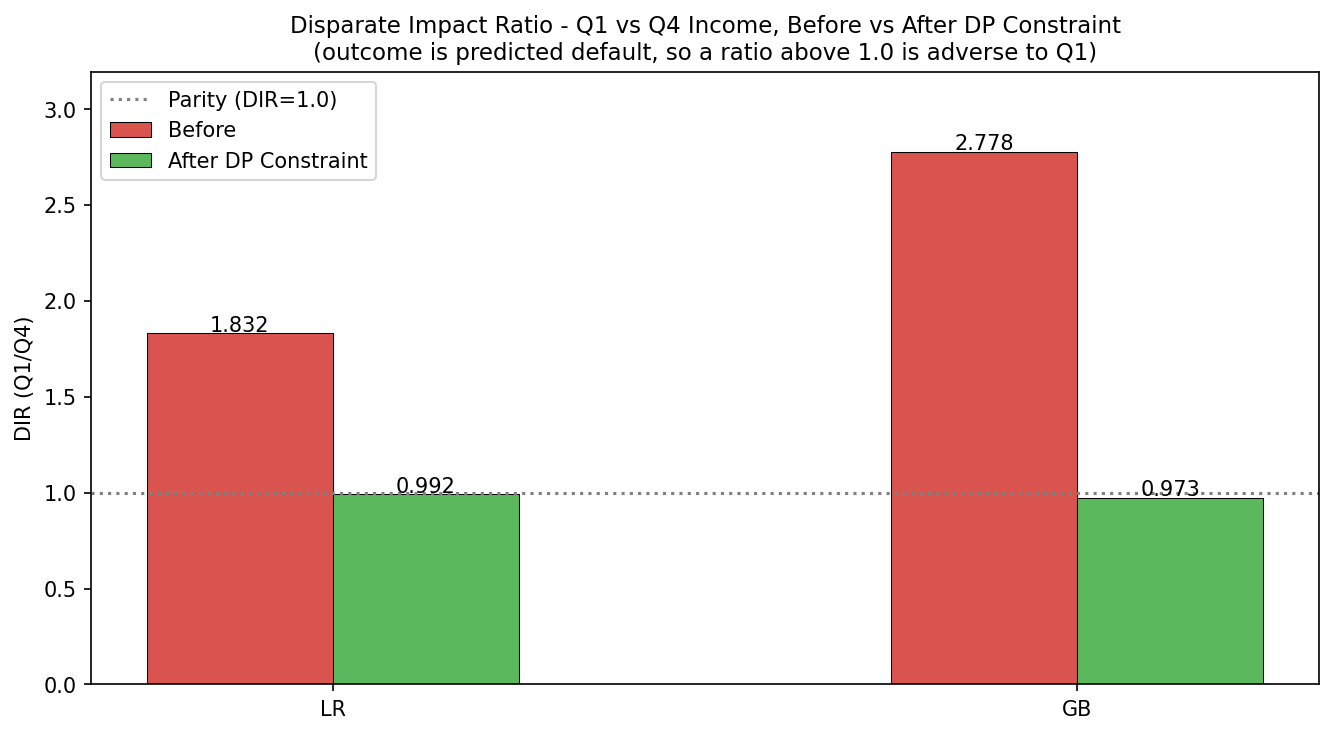

In [8]:
display(Image('figures/stage2/lendingclub_dir_before_after.png'))

## 7. F1 comparison

F1 score for each model at baseline and under the demographic parity constraint.

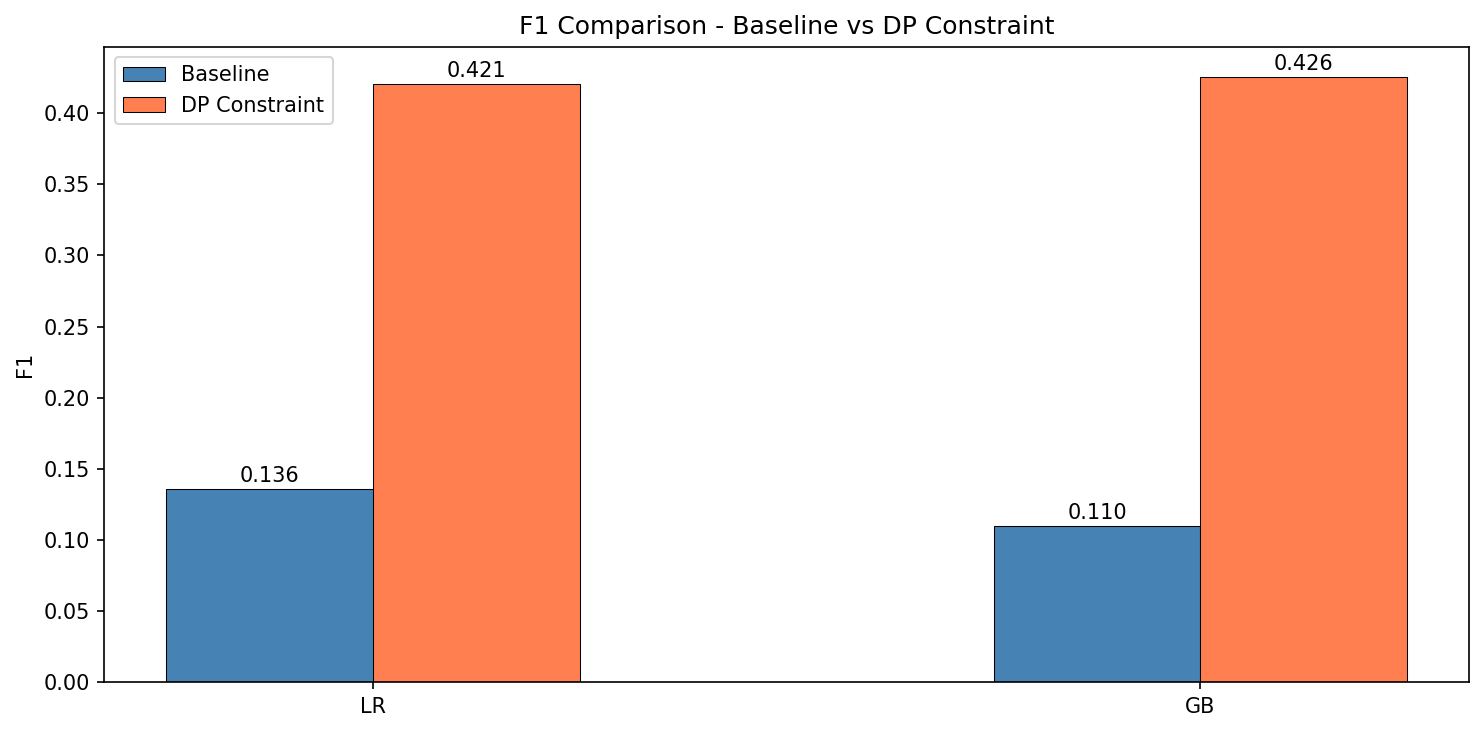

In [9]:
display(Image('figures/stage2/lendingclub_f1_comparison.png'))

## 8. FPR and FNR by income band

Gradient boosting's false positive and false negative rates for each income quartile, before and after the demographic parity constraint.

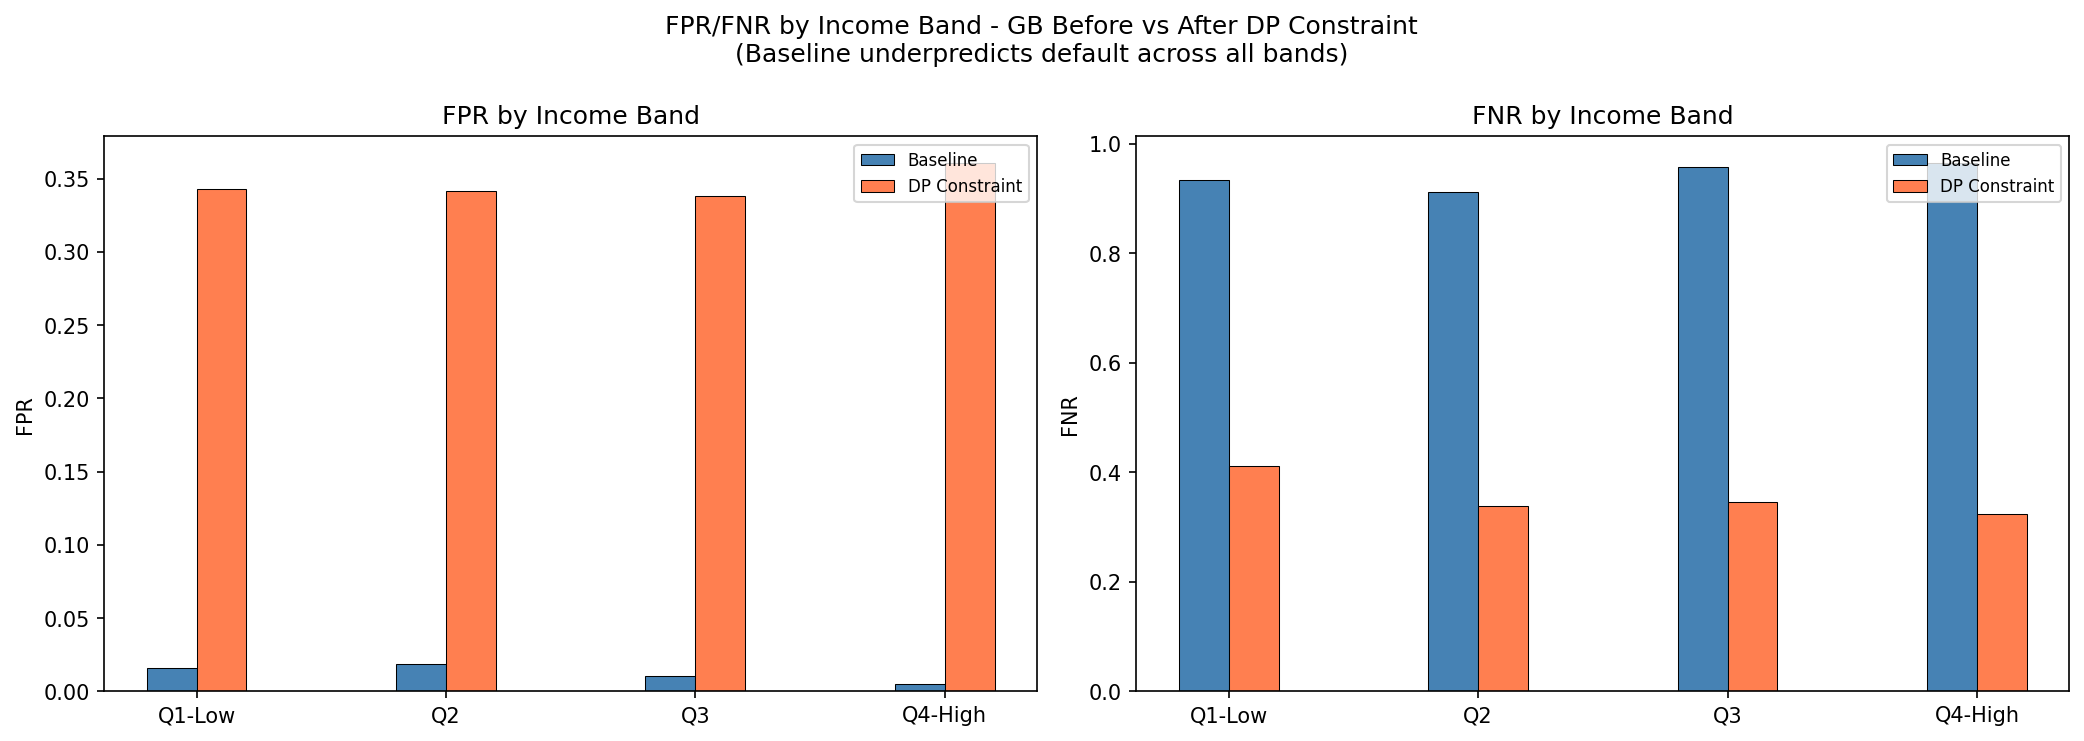

In [10]:
display(Image('figures/stage2/lendingclub_fpr_fnr_by_income.png'))

## Printed findings

The script's computed findings are in the output of the run cell above.